# Testing with Dask

Chatly for model testing

In [1]:
# setup imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [2]:
import warnings

import seaborn as sns
from dask import delayed
from dask.distributed import Client, progress
from ewatercycle.observation.grdc import get_grdc_data

from src.forcing import (
    generate_lumped_ERA5_forcing,
    load_lumped_forcing_data,
)
from src.models import *
from src.paths import *

warnings.filterwarnings("ignore", category=UserWarning)

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
shape_name = "Chatly_GRDC"
start_date = "1955-01-02T00:00Z"
end_date = "1959-12-31T00:00Z"


forcing = generate_lumped_ERA5_forcing(shape_name, start=start_date, end=end_date)

In [4]:
ERA5_forcing_loaded = load_lumped_forcing_data("Chatly_GRDC", "ERA5", "1955-1959")


grdc_station = get_grdc_data(
    2817100, "1955-01-02T00:00Z", "1959-12-31T00:00Z", data_home=GRDC / "Daily"
)


q_obs = grdc_station["streamflow"]
years = q_obs["time"].dt.year.values

In [5]:
# CMA-ES test setup
x0_norm = scale(0.5 * (p_min + p_max))  # start in the middle
sigma0 = 0.1  # step size in normalized space

# Define 20 unique seeds
seeds = [
    180988,
    214025,
    987654,
    123456,
    654321,
    111222,
    333444,
    555666,
    777888,
    999000,
    112233,
    445566,
    778899,
    101010,
    202020,
    303030,
    404040,
    505050,
    606060,
    707070,
]

In [6]:
# Create a Dask client with 3 workers, 1 thread each, dashboard auto-assigned
client = Client(n_workers=3, threads_per_worker=1, dashboard_address=":0")

# Display client info (clickable dashboard link appears in Jupyter)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:36191/status,
Dashboard: http://127.0.0.1:36191/status,Workers: 3
Total threads: 3,Total memory: 31.34 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34641,Workers: 3
Dashboard: http://127.0.0.1:36191/status,Total threads: 3
Started: Just now,Total memory: 31.34 GiB
Comm: tcp://127.0.0.1:42939,Total threads: 1
Dashboard: http://127.0.0.1:43027/status,Memory: 10.45 GiB
Nanny: tcp://127.0.0.1:46451,


In [7]:
objective_fn = make_objective_safe(ERA5_forcing_loaded, q_obs.values, shape_name)
number_runs = 12
test_seeds = seeds[:number_runs]

tasks = [
    delayed(run_cma)(
        cma_seed=s,
        x0_norm=x0_norm,
        sigma0=sigma0,
        objective_fn=objective_fn,
        popsize=16,
        maxfevals=240,
        save_folder="results_chatly_1/",
    )
    for s in test_seeds
]

# Submit tasks to the cluster
futures = client.compute(tasks)

# Optional: see a live progress bar
progress(futures)

# Gather results when done
results = client.gather(futures)

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 9 (seed=111222, Mon Feb  2 15:49:48 2026)
(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 9 (seed=555666, Mon Feb  2 15:49:48 2026)
(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 9 (seed=445566, Mon Feb  2 15:49:48 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     16 4.754006070411322e-01 1.0e+00 9.30e-02  9e-02  1e-01 2:10.9
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     16 4.536708541344868e-01 1.0e+00 9.78e-02  9e-02  1e-01 2:12.1
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     16 4.348568229087095e-01 1.0e+00 9.57e-02  9e-02  1e-01 2:13.8
    2     32 3.357178983976464e-01 1.2e+00 9.48e-02  9e-02  1e-01 4:22.6
    2     32 3.804237272045362e-01 1.3e+00 9.94e-02  9e-02  1e-01 4:24.1
    2     32 3.637982515659428e-01 1.2e+00 1.01e-01  1e-01  1e-01 4:26.7
    3     48 3.713423324939280e-01 1.4e+00 9.60e-02  9e-02  1e-01 6:34.0


In [8]:
# Convert results (list of dicts) to a nice table
df_results = pd.DataFrame(results)

# Optional: reorder columns
df_results = df_results[["seed", "best_f", "best_x", "nfev"]]

# Display nicely
df_results

,seed,best_f,best_x,nfev
0,180988,0.217062,"[0.5148016492106167, 0.6543093595718945, 0.463...",256
1,214025,0.215369,"[0.4589383450638046, 0.4640272798387489, 0.472...",256
2,987654,0.219806,"[0.982373971212845, 0.8512845501511496, 0.4040...",256
3,123456,0.234117,"[0.04524810365382544, 0.8888668382515742, 0.65...",256
4,654321,0.210937,"[0.5172235624768309, 0.6766995286689955, 0.726...",256
5,111222,0.216903,"[0.8247358990382477, 0.9553673108764578, 0.440...",256
6,333444,0.231031,"[0.7711555042334018, 0.7320688059118555, 0.471...",256
7,555666,0.208826,"[0.7021368803538306, 0.7423126652097044, 0.534...",256
8,777888,0.219814,"[0.45858794024427857, 0.6648204400810654, 0.50...",256
9,999000,0.213132,"[0.6926925721533583, 0.9931339806153051, 0.450...",256


In [9]:
import pickle
from pathlib import Path

results_folder = Path("results_5")
result_files = list(results_folder.glob("result_seed_*.pkl"))

loaded_results = []
for f in result_files:
    with open(f, "rb") as file:
        res = pickle.load(file)
        loaded_results.append(res)

# Example: print best objective per seed
for r in loaded_results:
    print(f"Seed {r['seed']}: best_f = {r['best_f']}, nfev = {r['nfev']}")

In [10]:
best_params_list = []

for run_idx, run in enumerate(results):
    seed = run["seed"]
    history = run["history"]

    # find the best evaluation by objective value
    best_idx = np.argmin(history["objective"])

    best_theta_phys = history["theta_phys"][best_idx]
    best_obj = history["objective"][best_idx]
    best_nse = history["nse"][best_idx]
    best_kge = history["kge"][best_idx]
    best_vol_err = history["vol_err"][best_idx]

    row = {
        "seed": seed,
        "best_eval": best_idx + 1,
        "objective": best_obj,
        "nse": best_nse,
        "kge": best_kge,
        "vol_err": best_vol_err,
    }

    # add each parameter with its proper name
    for i, th in enumerate(best_theta_phys):
        row[parameter_names[i]] = th

    best_params_list.append(row)

# create DataFrame
best_params_df = pd.DataFrame(best_params_list)
best_params_df

,seed,best_eval,objective,nse,kge,vol_err,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
0,180988,67,0.217062,0.543950,0.732989,0.000359,12.870041,0.723447,392.021142,1.425044,0.166052,8.872951,0.014085,0.005323,0.146706
1,214025,127,0.215369,0.580307,0.709886,0.006068,11.473459,0.571222,399.170543,1.179070,0.163511,11.660947,0.012343,0.009855,0.128778
2,987654,222,0.219806,0.532838,0.736421,0.001461,24.559349,0.881028,347.058639,1.696778,0.173765,7.118759,0.013904,0.006312,0.160711
3,123456,148,0.234117,0.510519,0.728728,0.014729,1.131203,0.911093,535.478765,1.788530,0.140389,14.548984,0.014216,0.004610,0.196460
4,654321,167,0.210937,0.598651,0.710792,0.009424,12.930589,0.741360,592.443142,1.238588,0.079507,8.923546,0.013505,0.006408,0.115891
5,111222,136,0.216903,0.589957,0.690627,0.002695,20.618397,0.964294,374.698438,1.535466,0.049965,9.434951,0.011321,0.004899,0.107613
6,333444,230,0.231031,0.598020,0.645490,0.010211,19.278888,0.785655,398.096943,1.594260,0.277283,9.259891,0.010729,0.009717,0.145867
7,555666,91,0.208826,0.598663,0.708818,0.002675,17.553422,0.793850,445.949088,1.383536,0.140063,8.537393,0.012999,0.007007,0.118738
8,777888,228,0.219814,0.578740,0.698556,0.007507,11.464699,0.731856,421.091700,1.394026,0.241584,8.329526,0.013793,0.002479,0.120420
9,999000,256,0.213132,0.572314,0.726534,0.006965,17.317314,0.994507,382.167141,1.764694,0.131941,9.608822,0.011920,0.001660,0.157763


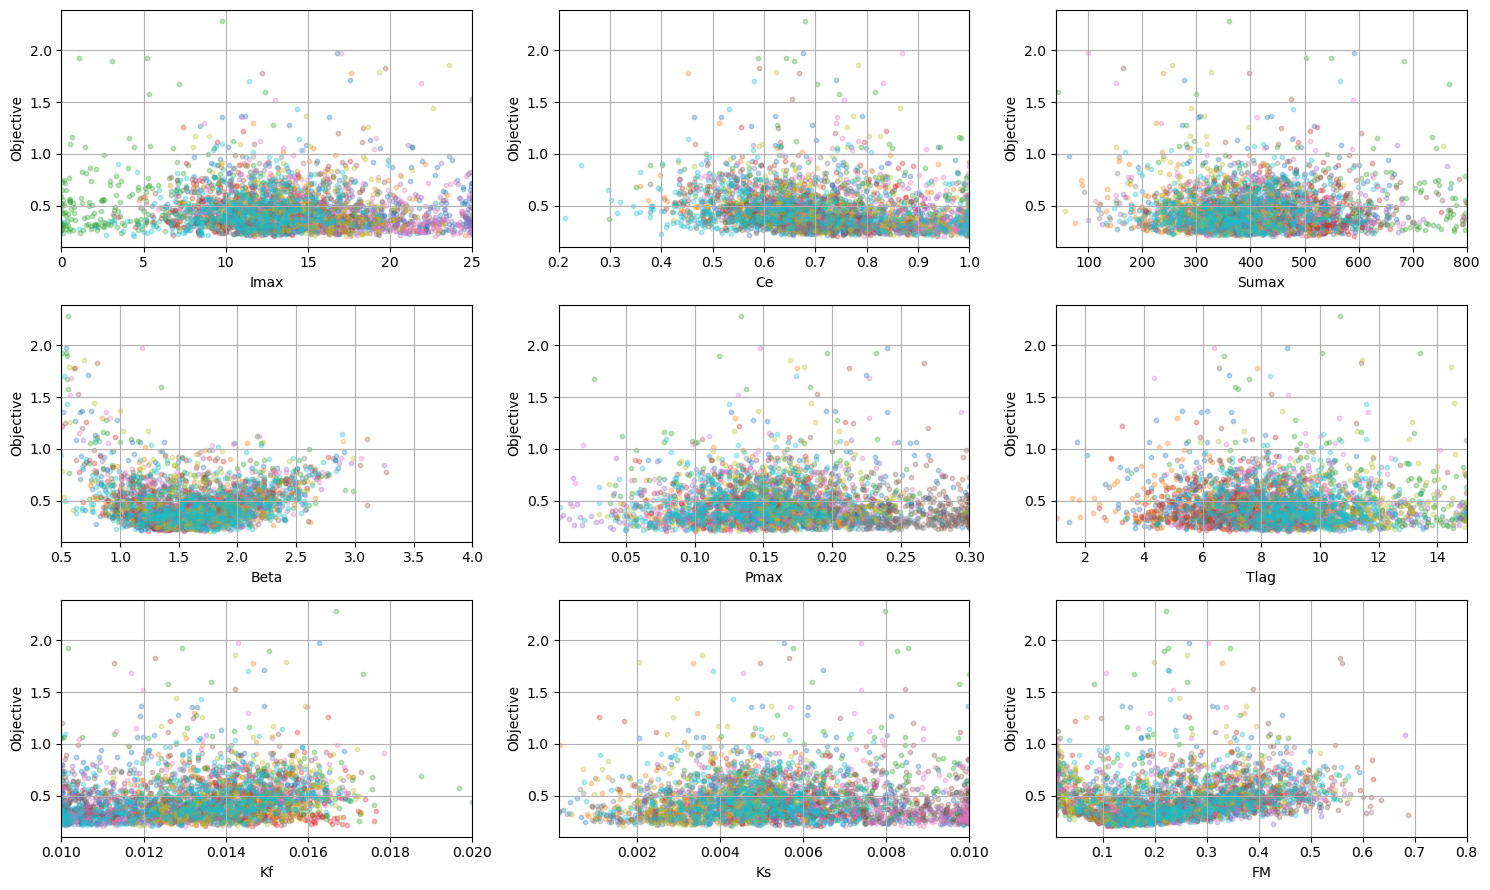

In [11]:
import numpy as np
import pandas as pd

# Suppose you have multiple seeds in `results`:
dfs = []
for seed_idx, res_seed in enumerate(results):
    hist = res_seed["history"]
    df = pd.DataFrame(hist)
    df["seed"] = seed_idx  # add a seed column
    dfs.append(df)

history_df = pd.concat(dfs, ignore_index=True)

n_params = len(p_min)  # 9
seeds = history_df["seed"].unique()  # get all unique seeds
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))  # assign colors

n_cols = 3
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
axes = axes.flatten()  # flatten for easy indexing

for i in range(n_params):
    ax = axes[i]

    for seed, color in zip(seeds, colors):
        theta_array = np.stack(history_df.loc[history_df["seed"] == seed, "theta_phys"].values)
        obj_array = history_df.loc[history_df["seed"] == seed, "objective"].values
        ax.scatter(theta_array[:, i], obj_array, label=f"Seed {seed}", color=color, alpha=0.3, s=10)
        ax.set_xlabel(parameter_names[i])

    ax.set_ylabel("Objective")
    # ax.set_title()
    ax.set_xlim(p_min[i], p_max[i])
    ax.grid(True)

# remove empty axes
for j in range(n_params, len(axes)):
    fig.delaxes(axes[j])


# axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

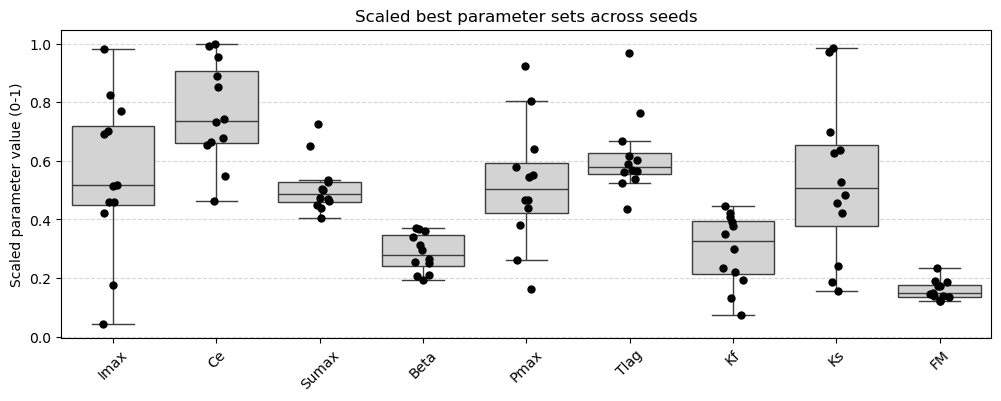

In [12]:
# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Scale the best parameters
scaled_params_df = pd.DataFrame(scale(best_params_df[param_cols].to_numpy()), columns=param_cols)


plt.figure(figsize=(12, 4))
# sns.boxplot(data=scaled_params_df, color = 'lightgray')
# sns.stripplot(data=scaled_params_df, color='black', jitter=False, size=8)
sns.boxplot(
    data=scaled_params_df, color="lightgray", fliersize=0
)  # light gray boxes, hide default outliers
sns.stripplot(data=scaled_params_df, color="black", jitter=True, size=6, marker="o")  # black dots

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title("Scaled best parameter sets across seeds")
# add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [13]:
from dask.distributed import Client

# Assuming you created a client earlier
client.close()  # closes client and shuts down local cluster/workers